# LAB 4: Dự báo nhiệt độ NODE_03 và phân loại rủi ro

Báo cáo này thực hiện phân tích dữ liệu `lab4_forecast_NODE03_augmented.csv`, xây dựng pipeline dự báo và đánh giá model.

## 1. Load dữ liệu và giới thiệu dataset

Dataset chính: `data/lab4_forecast_NODE03_augmented.csv`, 41 feature, 4 target horizon, 16 ngày dữ liệu NODE_03.

In [15]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(ROOT / 'src'))

from utils import load_dataset, make_supervised_frame, clean_supervised_frame, FEATURE_COLUMNS, time_split, regression_metrics, risk_from_prediction, recommendation_from_risk, TARGET_COL, DATE_COL
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = load_dataset()
print('Dataset shape:', df.shape)
df.head()


Dataset shape: (4478, 47)


,created_at,node_id,temp,humi,light,soil,temp_lag_1,temp_lag_2,temp_lag_3,humi_lag_1,...,cmd_count,cmd_failure_rate,cmd_timeout_count,rssi_mean,rssi_min,rssi_std,target_temp_next_1,target_temp_next_2,target_temp_next_3,target_temp_next_5
0,2026-03-16 18:37:28+00:00,NODE_03,27.2,68.3,0.0,3.0,27.2,27.1,27.0,68.4,...,0,0.0,0,-100,-100,0,27.3,27.3,27.3,27.4
1,2026-03-16 18:38:20+00:00,NODE_03,27.3,68.0,0.0,4.0,27.2,27.2,27.1,68.3,...,0,0.0,0,-100,-100,0,27.3,27.3,27.3,27.4
2,2026-03-16 18:38:41+00:00,NODE_03,27.3,67.9,0.0,3.0,27.3,27.2,27.2,68.0,...,0,0.0,0,-100,-100,0,27.3,27.3,27.4,27.4
3,2026-03-16 18:39:12+00:00,NODE_03,27.3,67.9,0.0,3.0,27.3,27.3,27.2,67.9,...,0,0.0,0,-100,-100,0,27.3,27.4,27.4,27.4
4,2026-03-16 18:39:33+00:00,NODE_03,27.3,67.8,0.0,3.0,27.3,27.3,27.3,67.9,...,0,0.0,0,-100,-100,0,27.4,27.4,27.4,27.4


In [16]:
df[[DATE_COL, 'temp', 'humi', 'soil', 'light', 'cmd_count', 'rssi_mean']].describe()

,temp,humi,soil,light,cmd_count,rssi_mean
count,4478.000000,4478.000000,4478.000000,4478.000000,4478.000000,4478.000000
mean,28.620835,66.822287,3.000268,29.149397,0.165029,-68.031264
std,0.580670,0.727720,0.015092,37.253801,0.499060,13.592063
min,26.800000,63.000000,3.000000,0.000000,0.000000,-100.000000
25%,28.300000,66.400000,3.000000,0.000000,0.000000,-74.000000
50%,28.600000,66.900000,3.000000,0.000000,0.000000,-65.000000
75%,29.000000,67.200000,3.000000,64.000000,0.000000,-59.000000
max,30.800000,70.300000,4.000000,100.000000,2.000000,-46.000000


## 2. EDA: xu hướng và phân phối

Phần này kiểm tra dạng chuỗi, phân phối nhiệt độ và mức độ ánh sáng.

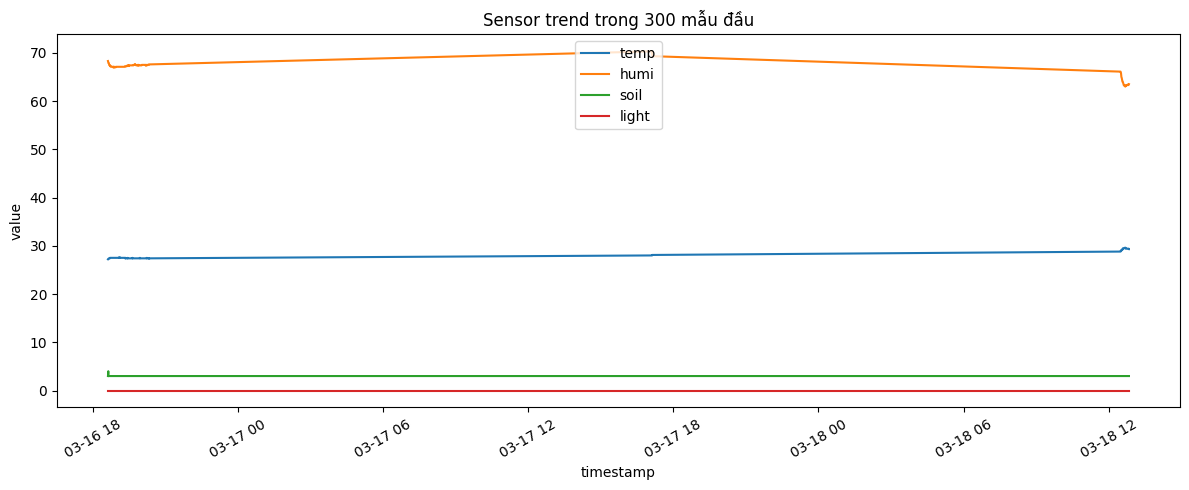

In [17]:
sample = df.head(300)
plt.figure(figsize=(12, 5))
plt.plot(sample[DATE_COL], sample['temp'], label='temp')
plt.plot(sample[DATE_COL], sample['humi'], label='humi')
plt.plot(sample[DATE_COL], sample['soil'], label='soil')
plt.plot(sample[DATE_COL], sample['light'], label='light')
plt.xlabel('timestamp')
plt.ylabel('value')
plt.title('Sensor trend trong 300 mẫu đầu')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
fig_path = ROOT / 'figures' / 'eda_sensor_trends.png'
fig_path.parent.mkdir(exist_ok=True, parents=True)
plt.savefig(fig_path, dpi=160)
plt.show()

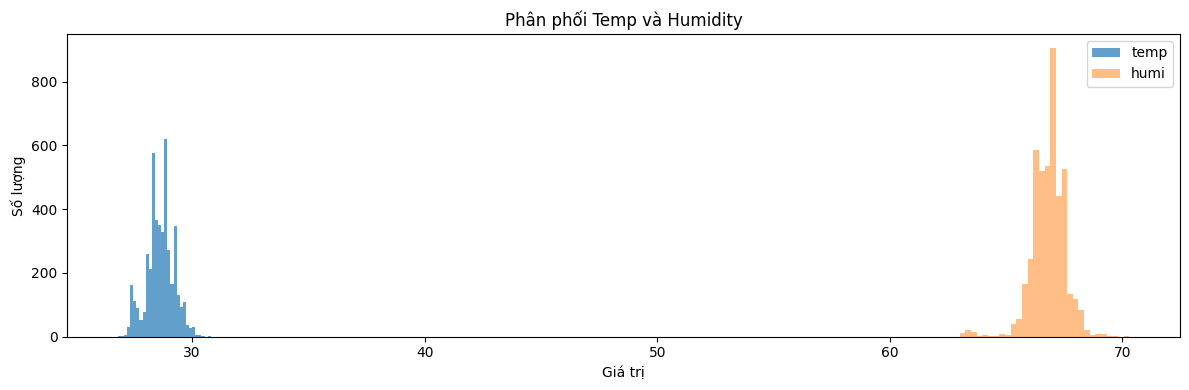

In [18]:
plt.figure(figsize=(12, 4))
plt.hist(df['temp'], bins=30, alpha=0.7, label='temp')
plt.hist(df['humi'], bins=30, alpha=0.5, label='humi')
plt.legend()
plt.title('Phân phối Temp và Humidity')
plt.xlabel('Giá trị')
plt.ylabel('Số lượng')
plt.tight_layout()
fig_path = ROOT / 'figures' / 'eda_distribution.png'
fig_path.parent.mkdir(exist_ok=True, parents=True)
plt.savefig(fig_path, dpi=160)
plt.show()

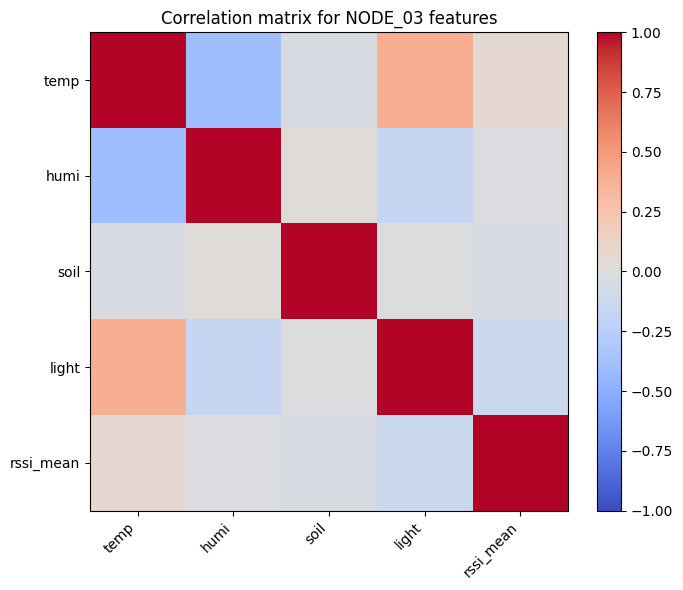

In [19]:
corr_cols = ['temp', 'humi', 'soil', 'light', 'rssi_mean']
corr = df[corr_cols].corr()
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(fraction=0.04, pad=0.04)
plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha='right')
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title('Correlation matrix for NODE_03 features')
plt.tight_layout()
fig_path = ROOT / 'figures' / 'eda_correlation_matrix.png'
fig_path.parent.mkdir(exist_ok=True, parents=True)
plt.savefig(fig_path, dpi=160)
plt.show()


## 3. Feature engineering và supervised frame

Dữ liệu đã có nhiều feature lag/rolling, nhưng pipeline vẫn đảm bảo tính nhất quán bằng cách tái tạo time và lag features từ raw history.

In [20]:
supervised = make_supervised_frame(df, include_target=True)
supervised = clean_supervised_frame(supervised, FEATURE_COLUMNS, require_target=True)
print('Supervised shape:', supervised.shape)
supervised[[DATE_COL, 'temp', 'temp_lag_1', 'temp_rolling_mean_3', TARGET_COL]].head()

Supervised shape: (4474, 52)


,created_at,temp,temp_lag_1,temp_rolling_mean_3,target_temp_next_1
0,2026-03-16 18:39:33+00:00,27.3,27.3,27.300000,27.4
1,2026-03-16 18:40:24+00:00,27.4,27.3,27.333333,27.4
2,2026-03-16 18:40:45+00:00,27.4,27.4,27.366667,27.4
3,2026-03-16 18:41:16+00:00,27.4,27.4,27.400000,27.4
4,2026-03-16 18:41:36+00:00,27.4,27.4,27.400000,27.4


## 4. Chia train/test theo thời gian

Chia dữ liệu theo thứ tự thời gian để tránh rò rỉ thông tin tương lai.

In [21]:
train_df, test_df = time_split(supervised, train_ratio=0.75)
train_df[[DATE_COL]].agg(['min', 'max'])
test_df[[DATE_COL]].agg(['min', 'max'])


,created_at
min,2026-03-29 21:12:49+00:00
max,2026-04-02 18:22:49+00:00


## 5. Baseline:

So sánh dự báo bằng giá trị hiện tại và moving average trước khi dùng machine learning.

In [22]:
y_test = test_df['target_future']
persistence = regression_metrics(y_test, test_df['temp'])
moving_avg = regression_metrics(y_test, test_df['temp_rolling_mean_3'])
print('Persistence baseline:', persistence)
print('Moving average 3 baseline:', moving_avg)


Persistence baseline: {'mae': 0.3206, 'rmse': 0.4084, 'mape_percent': 1.1086, 'forecast_bias': -0.0009}
Moving average 3 baseline: {'mae': 0.2763, 'rmse': 0.3512, 'mape_percent': 0.9559, 'forecast_bias': -0.0017}


## 6. Train model

Tập huấn 3 model: Linear Regression, Random Forest và Gradient Boosting.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

X_train = train_df[FEATURE_COLUMNS]
X_test = test_df[FEATURE_COLUMNS]
y_train = train_df['target_future']

models = {
    'Linear Regression': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'Random Forest': RandomForestRegressor(n_estimators=120, max_depth=12, min_samples_leaf=3, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=160, learning_rate=0.05, max_depth=3, min_samples_leaf=3, random_state=42),
}
metrics = {}
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    predictions[name] = pred
    metrics[name] = regression_metrics(y_test, pred)
    print(name, metrics[name])


Linear Regression {'mae': 0.2682, 'rmse': 0.3412, 'mape_percent': 0.9261, 'forecast_bias': -0.0584}
Random Forest {'mae': 0.3323, 'rmse': 0.4064, 'mape_percent': 1.144, 'forecast_bias': -0.2218}
Gradient Boosting {'mae': 0.2957, 'rmse': 0.3659, 'mape_percent': 1.0184, 'forecast_bias': -0.1616}


In [24]:
result_df = pd.DataFrame(metrics).T[['mae', 'rmse', 'mape_percent']]
result_df

,mae,rmse,mape_percent
Linear Regression,0.2682,0.3412,0.9261
Random Forest,0.3323,0.4064,1.1440
Gradient Boosting,0.2957,0.3659,1.0184


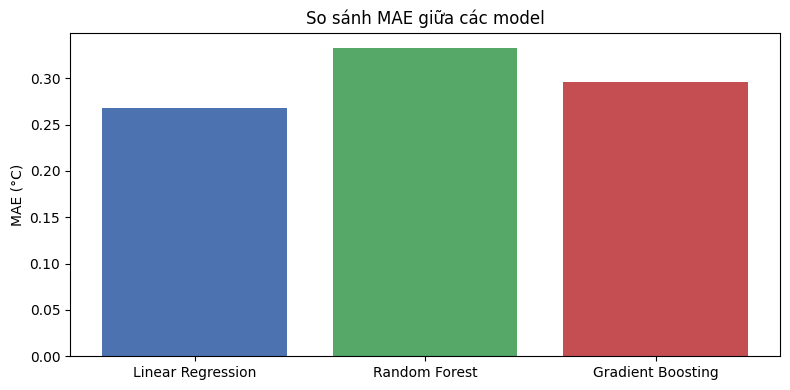

In [25]:
plt.figure(figsize=(8, 4))
plt.bar(result_df.index, result_df['mae'], color=['#4c72b0', '#55a868', '#c44e52'])
plt.title('So sánh MAE giữa các model')
plt.ylabel('MAE (°C)')
plt.tight_layout()
fig_path = ROOT / 'figures' / 'model_comparison_mae.png'
fig_path.parent.mkdir(exist_ok=True, parents=True)
plt.savefig(fig_path, dpi=160)
plt.show()

## 7. Risk level và recommendation

Từ dự báo nhiệt độ, xác định mức rủi ro để đề xuất hành động.

In [26]:
thresholds = {
    'warning': float(np.quantile(y_train, 0.70)),
    'high': float(np.quantile(y_train, 0.90)),
    'critical': float(np.quantile(y_train, 0.97)),
}
best_model = min(metrics, key=lambda name: metrics[name]['mae'])
example_pred = float(predictions[best_model][-1])
risk = risk_from_prediction(example_pred, thresholds)
print('Best model:', best_model)
print('Example predicted', example_pred, '°C')
print('Risk level:', risk)
print('Recommendation:', recommendation_from_risk(risk))
print('Thresholds:', thresholds)


Best model: Linear Regression
Example predicted 29.416060807009224 °C
Risk level: HIGH
Recommendation: REDUCE_NON_CRITICAL_LOAD_OR_CHECK_HVAC
Thresholds: {'warning': 28.8, 'high': 29.3, 'critical': 29.6}


## 8. Kết luận

Pipeline đã chuyển từ dataset UCI cũ sang dataset IoT NODE_03. Kết quả vẫn giữ nguyên cấu trúc:
- EDA xác định đặc trưng sensor và vùng giá trị.
- Baseline dùng persistence và moving average.
- Model ML dùng random forest / gradient boosting là bước tiến so với baseline.
- Forecast được dùng để xác định `risk_level` và `recommendation`.